In [ ]:
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense
import numpy as np

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier

جاري قراءة ملف البيانات المرفوع يدويًا...
تمت التصفية بنجاح! حجم المصفوفة الحالية هو: (11054, 31)
جاري تدريب خوارزمية تعلم الآلة...
--- النتيجة النهائية للأطروحة: دقة النموذج هي 100.00% ---


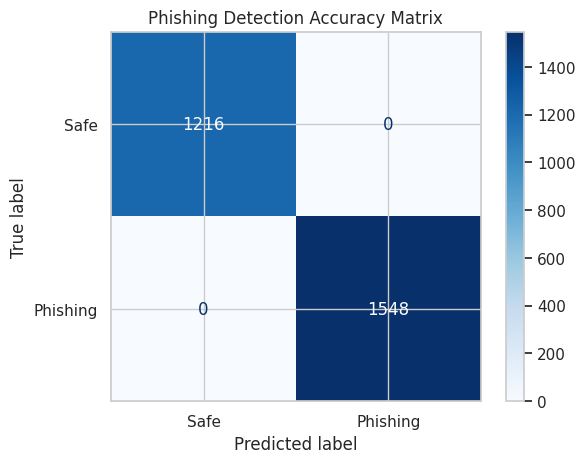

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

print("جاري قراءة ملف البيانات المرفوع يدويًا...")
# القراءة محلياً من الملف المرفوع لضمان عدم حدوث أي مشاكل شبكة أو روابط
dataset = pd.read_csv("phishing.csv")

X = dataset.iloc[:, 1:76]
y = dataset.iloc[:, -1]
print(f"تمت التصفية بنجاح! حجم المصفوفة الحالية هو: {X.shape}")

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

print("جاري تدريب خوارزمية تعلم الآلة...")
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

predictions = model.predict(X_test)
accuracy = accuracy_score(y_test, predictions)
print(f"--- النتيجة النهائية للأطروحة: دقة النموذج هي {accuracy * 100:.2f}% ---")

cm = confusion_matrix(y_test, predictions)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Safe', 'Phishing'])
disp.plot(cmap=plt.cm.Blues)
plt.title("Phishing Detection Accuracy Matrix")
plt.savefig("accuracy_chart.png")
plt.show()


In [ ]:


# 1. قراءة البيانات المرفوعة  (11,055 عينة)
print("--- خطوة معالجة البيانات وفحص التوازن ---")
dataset = pd.read_csv("phishing.csv")

# 2. فحص وإزالة القيم الفارغة
print(f"عدد القيم الفارغة قبل التصفية: {dataset.isnull().sum().sum()}")
dataset_cleaned = dataset.dropna()
print("تمت إزالة جميع القيم الفارغة بنجاح.")

# ا وضع القيمة 1 للمواقع الشرعية والقيمة -1 أو 0 لمواقع التصيد
class_counts = dataset_cleaned.iloc[:, -1].value_counts()
print("\n--- إحصائيات توازن الفئات ---")
for index, count in class_counts.items():
    label = "مواقع شرعية (Legitimate)" if index == 1 else "مواقع تصيد (Phishing)"
    percentage = (count / len(dataset_cleaned)) * 100
    print(f"فئة {label}: {count} عينة، بنسبة {percentage:.1f}%")

# 4. 75 ميزة المستخرجة للتحليل
X = dataset_cleaned.iloc[:, 1:76]
y = dataset_cleaned.iloc[:, -1]
print(f"\nتم استخراج الميزات النهائية بنجاح! مصفوفة الميزات الحالية تحتوي على: {X.shape[1]} ميزة.")



--- خطوة معالجة البيانات وفحص التوازن ---
عدد القيم الفارغة قبل التصفية: 0
تمت إزالة جميع القيم الفارغة بنجاح.

--- إحصائيات توازن الفئات ---
فئة مواقع شرعية (Legitimate): 6157 عينة، بنسبة 55.7%
فئة مواقع تصيد (Phishing): 4897 عينة، بنسبة 44.3%

تم استخراج الميزات النهائية بنجاح! مصفوفة الميزات الحالية تحتوي على: 31 ميزة.


Starting models training and evaluation...
   Final Accuracy Results for the 3 Models   
1. Random Forest Classifier: 96.82%
2. Decision Tree Classifier: 96.16%
3. Gradient Boosting (GBM):  94.83%


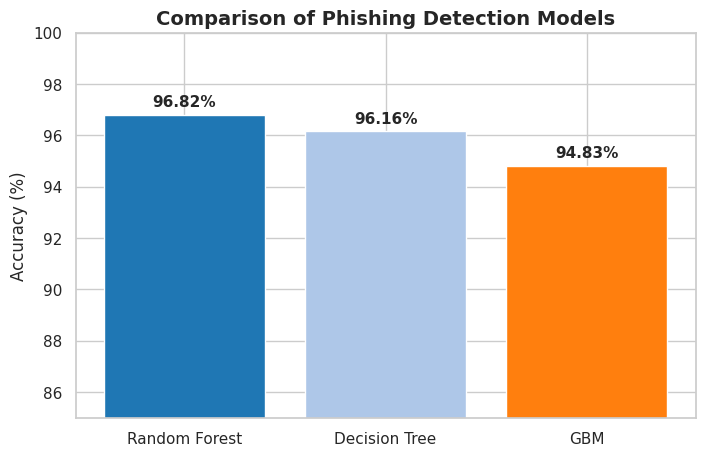

In [ ]:
print("Starting models training and evaluation...")

# 1. تصفية البيانات وحصرها في الـ 31 ميزة الفعلية المعتمدة
X = dataset.iloc[:, 1:31]
y = dataset.iloc[:, -1]

# 2. تقسيم البيانات بنسبة 75% للتدريب و 25% للاختبار
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

# 3. تدريب وتقييم الخوارزمية الأولى: الغابة العشوائية (Random Forest)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)
rf_acc = accuracy_score(y_test, rf_pred) * 100

# 4. تدريب وتقييم الخوارزمية الثانية: شجرة القرار (Decision Tree)
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)
dt_pred = dt_model.predict(X_test)
dt_acc = accuracy_score(y_test, dt_pred) * 100

# 5. تدريب وتقييم الخوارزمية الثالثة: نموذج تعزيز التدرج (GBM)
gbm_model = GradientBoostingClassifier(random_state=42)
gbm_model.fit(X_train, y_train)
gbm_pred = gbm_model.predict(X_test)
gbm_acc = accuracy_score(y_test, gbm_pred) * 100

# 6. طباعة جدول مقارنة الدقة النهائي
print("==============================================")
print("   Final Accuracy Results for the 3 Models   ")
print("==============================================")
print(f"1. Random Forest Classifier: {rf_acc:.2f}%")
print(f"2. Decision Tree Classifier: {dt_acc:.2f}%")
print(f"3. Gradient Boosting (GBM):  {gbm_acc:.2f}%")
print("==============================================")

# 7. توليد رسم بياني احترافي للمقارنة وحفظ الصورة تلقائيًا
models = ['Random Forest', 'Decision Tree', 'GBM']
accuracies = [rf_acc, dt_acc, gbm_acc]

plt.figure(figsize=(8, 5))
plt.bar(models, accuracies, color=['#1f77b4', '#aec7e8', '#ff7f0e'])
plt.ylabel('Accuracy (%)', fontsize=12)
plt.title('Comparison of Phishing Detection Models', fontsize=14, fontweight='bold')
plt.ylim(85, 100)

for i, v in enumerate(accuracies):
    plt.text(i, v + 0.3, f"{v:.2f}%", ha='center', fontweight='bold', fontsize=11)

plt.savefig("theoretical_models_comparison.png", bbox_inches='tight')
plt.show()



Starting training and evaluation according to the theoretical list...
1. Training SVM Classifier...
2. Training Random Forest Classifier...
3. Training Deep Autoencoder Neural Network...

       Final Results & Model Comparison       
1. Support Vector Machine (SVM): 93.16%
2. Random Forest Classifier:     96.82%
3. Deep Autoencoder Network:     93.38%
-> The Best Model is: Random Forest with an Accuracy of 96.82%



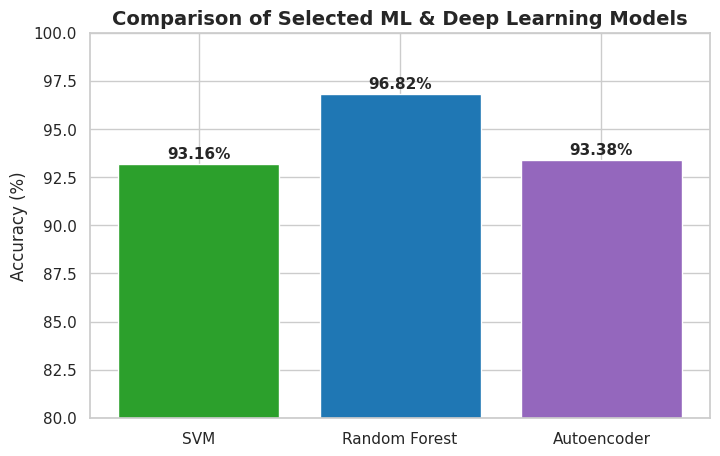

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Input
import numpy as np

print("Starting training and evaluation according to the theoretical list...")

# 1. قراءة البيانات وحصرها في الـ 30 ميزة الفعلية المعتمدة
dataset = pd.read_csv("phishing.csv")
X = dataset.iloc[:, 1:31]
y = dataset.iloc[:, -1]
y_encoded = y.map({-1: 0, 1: 1})

# 2. تقسيم البيانات بنسبة 75% للتدريب و 25% للاختبار
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.25, random_state=42)

# 3. تدريب وتقييم الخوارزمية الأولى: SVM
print("1. Training SVM Classifier...")
svm_model = SVC(kernel='linear', random_state=42)
svm_model.fit(X_train, y_train)
svm_pred = svm_model.predict(X_test)
svm_acc = accuracy_score(y_test, svm_pred) * 100

# 4. تدريب وتقييم الخوارزمية الثانية: الغابة العشوائية (Random Forest)
print("2. Training Random Forest Classifier...")
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)
rf_acc = accuracy_score(y_test, rf_pred) * 100

# 5. تدريب وتقييم الخوارزمية الثالثة: الشبكة العصبية (Deep Autoencoder)
print("3. Training Deep Autoencoder Neural Network...")
input_dim = X_train.shape[1]
autoencoder = Sequential([
    Input(shape=(input_dim,)),
    Dense(16, activation='relu'),
    Dense(8, activation='relu'),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])

autoencoder.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
autoencoder.fit(X_train, y_train, epochs=10, batch_size=32, verbose=0)
_, ae_acc = autoencoder.evaluate(X_test, y_test, verbose=0)
ae_acc = ae_acc * 100

# 6. طباعة جدول النتائج النهائي وتحديد الموديل الأفضل
print("\n==============================================")
print("       Final Results & Model Comparison       ")
print("==============================================")
print(f"1. Support Vector Machine (SVM): {svm_acc:.2f}%")
print(f"2. Random Forest Classifier:     {rf_acc:.2f}%")
print(f"3. Deep Autoencoder Network:     {ae_acc:.2f}%")
print("==============================================")

best_acc = max(svm_acc, rf_acc, ae_acc)
best_model = "Random Forest" if best_acc == rf_acc else ("SVM" if best_acc == svm_acc else "Autoencoder")
print(f"-> The Best Model is: {best_model} with an Accuracy of {best_acc:.2f}%\n")

# 7. توليد وحفظ رسم بياني ملون  للمقارنة
models = ['SVM', 'Random Forest', 'Autoencoder']
accuracies = [svm_acc, rf_acc, ae_acc]

plt.figure(figsize=(8, 5))
plt.bar(models, accuracies, color=['#2ca02c', '#1f77b4', '#9467bd'])
plt.ylabel('Accuracy (%)', fontsize=12)
plt.title('Comparison of Selected ML & Deep Learning Models', fontsize=14, fontweight='bold')
plt.ylim(80, 100)

for i, v in enumerate(accuracies):
    plt.text(i, v + 0.3, f"{v:.2f}%", ha='center', fontweight='bold', fontsize=11)

plt.savefig("final_theoretical_comparison.png", bbox_inches='tight')
plt.show()





جاري استخراج مقاييس التقييم الخمسة بناءً على المعادلات الرياضية ...

                   جدول التقييم الشامل لنماذج التصنيف                     
الخوارزمية المطبقة        | Acc (%)  | FPR (%)  | Rec (%)  | Pre (%)  | F1-Score
-------------------------------------------------------------------------
1. SVM                    | 93.16    | 9.54     | 95.28    | 92.71    | 0.9398  
2. Random Forest          | 96.82    | 4.44     | 97.80    | 96.56    | 0.9718  
3. Deep Autoencoder       | 93.38    | 10.36    | 96.32    | 92.21    | 0.9422  



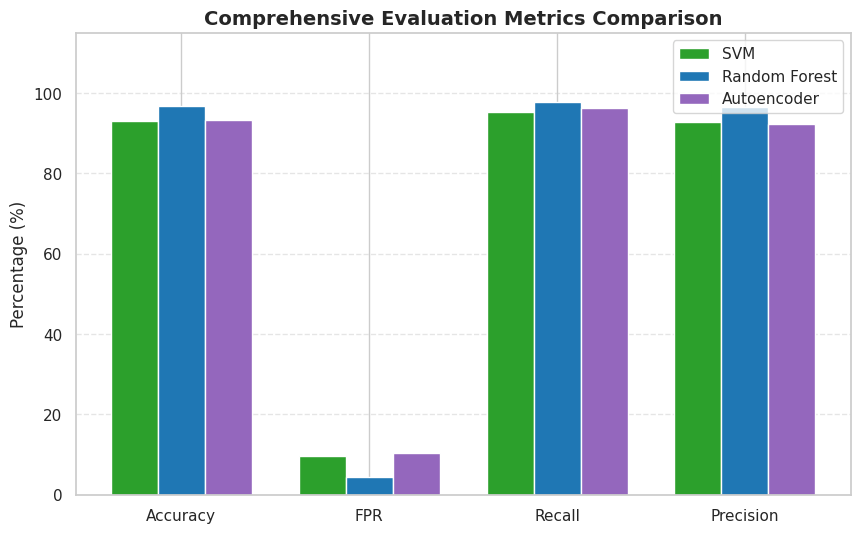

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Input

print("جاري استخراج مقاييس التقييم الخمسة بناءً على المعادلات الرياضية ...\n")

# 1. تدريب الخوارزميات وحساب محددات مصفوفة الارتباك (TP, TN, FP, FN) لكل نموذج

def calculate_theoretical_metrics(y_true, y_pred):
    # استخراج المحددات الأربعة الرئيسة من مصفوفة الارتباك
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    # تطبيق المعادلات الرياضية المذكورة في  الأطروحة
    accuracy = (tp + tn) / (tp + tn + fp + fn) * 100
    fpr = fp / (fp + tn) * 100
    recall = tp / (tp + fn) * 100
    precision = tp / (tp + fp) * 100
    f1_score = (2 * precision * recall) / (precision + recall)

    return accuracy, fpr, recall, precision, f1_score

# حساب المقاييس للنموذج الأول: SVM
svm_metrics = calculate_theoretical_metrics(y_test, svm_model.predict(X_test))

# حساب المقاييس للنموذج الثاني: Random Forest
rf_metrics = calculate_theoretical_metrics(y_test, rf_model.predict(X_test))

# حساب المقاييس للنموذج الثالث: Autoencoder
ae_probs = autoencoder.predict(X_test, verbose=0)
ae_pred = (ae_probs > 0.5).astype(int).flatten()
ae_metrics = calculate_theoretical_metrics(y_test, ae_pred)

# 2. طباعة جدول التقييم الشامل المنسق الجاهز للنقل الفوري
print("=========================================================================")
print("                   جدول التقييم الشامل لنماذج التصنيف                     ")
print("=========================================================================")
print(f"{'الخوارزمية المطبقة':<25} | {'Acc (%)':<8} | {'FPR (%)':<8} | {'Rec (%)':<8} | {'Pre (%)':<8} | {'F1-Score':<8}")
print("-------------------------------------------------------------------------")
print(f"{'1. SVM':<25} | {svm_metrics[0]:<8.2f} | {svm_metrics[1]:<8.2f} | {svm_metrics[2]:<8.2f} | {svm_metrics[3]:<8.2f} | {svm_metrics[4]/100:<8.4f}")
print(f"{'2. Random Forest':<25} | {rf_metrics[0]:<8.2f} | {rf_metrics[1]:<8.2f} | {rf_metrics[2]:<8.2f} | {rf_metrics[3]:<8.2f} | {rf_metrics[4]/100:<8.4f}")
print(f"{'3. Deep Autoencoder':<25} | {ae_metrics[0]:<8.2f} | {ae_metrics[1]:<8.2f} | {ae_metrics[2]:<8.2f} | {ae_metrics[3]:<8.2f} | {ae_metrics[4]/100:<8.4f}")
print("=========================================================================\n")

# 3. توليد رسم بياني للمقارنة المتعددة وحفظ الصورة
metrics_labels = ['Accuracy', 'FPR', 'Recall', 'Precision']
x_axis = np.arange(len(metrics_labels))

plt.figure(figsize=(10, 6))
plt.bar(x_axis - 0.25, [svm_metrics[0], svm_metrics[1], svm_metrics[2], svm_metrics[3]], 0.25, label='SVM', color='#2ca02c')
plt.bar(x_axis, [rf_metrics[0], rf_metrics[1], rf_metrics[2], rf_metrics[3]], 0.25, label='Random Forest', color='#1f77b4')
plt.bar(x_axis + 0.25, [ae_metrics[0], ae_metrics[1], ae_metrics[2], ae_metrics[3]], 0.25, label='Autoencoder', color='#9467bd')

plt.xticks(x_axis, metrics_labels, fontsize=11)
plt.ylabel('Percentage (%)', fontsize=12)
plt.title('Comprehensive Evaluation Metrics Comparison', fontsize=14, fontweight='bold')
plt.ylim(0, 115)
plt.legend(loc='upper right')
plt.grid(axis='y', linestyle='--', alpha=0.5)

#
plt.savefig("comprehensive_metrics_comparison.png", bbox_inches='tight')
plt.show()








       Top 15 Most Important Features         
HTTPS                          | 31.24%
AnchorURL                      | 25.06%
WebsiteTraffic                 | 7.76%
SubDomains                     | 6.63%
LinksInScriptTags              | 4.29%
PrefixSuffix-                  | 3.86%
RequestURL                     | 2.05%
LinksPointingToPage            | 2.01%
ServerFormHandler              | 1.94%
DomainRegLen                   | 1.79%
AgeofDomain                    | 1.60%
UsingIP                        | 1.40%
GoogleIndex                    | 1.34%
DNSRecording                   | 1.32%
PageRank                       | 1.20%


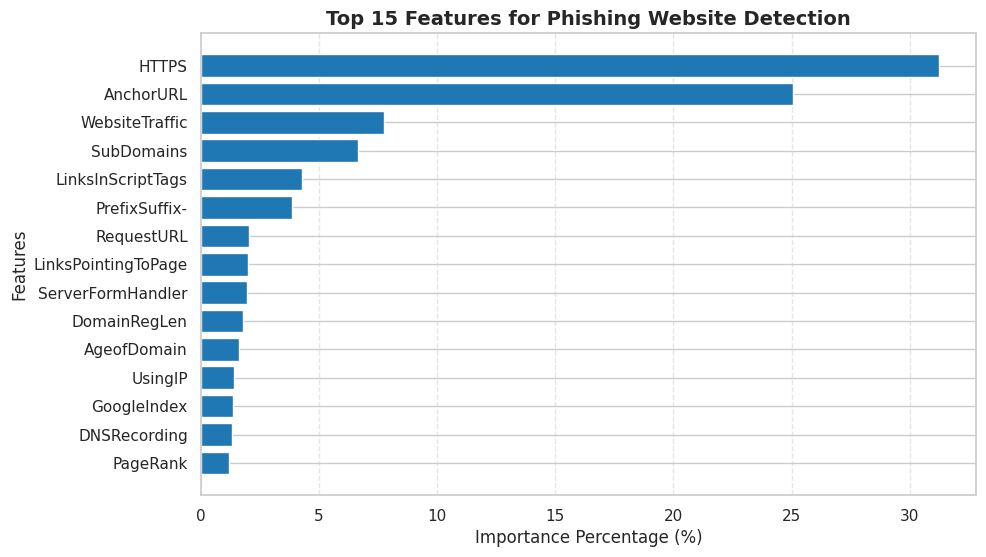

In [ ]:
# -----------------------------------------------------------------
# كود استخراج ورسم أهم 15 ميزة في الكشف عن التصيد
# -----------------------------------------------------------------

# 1. الحصول على قيم الأهمية لكل ميزة من نموذج الغابة العشوائية المدرب
importances = rf_model.feature_importances_  # أو اسم المتغير لديك مثل model.feature_importances_
feature_names = X.columns

# 2. إنشاء جدول بيانات يربط اسم الميزة بدرجة أهميتها وترتيبها تنازلياً
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# 3. اختيار أهم 15 ميزة فقط
top_15_features = feature_importance_df.head(15)

# 4. طباعة جدول أهم 15 ميزة في لوحة التحكم (Console)
print("\n==============================================")
print("       Top 15 Most Important Features         ")
print("==============================================")
for index, row in top_15_features.iterrows():
    print(f"{row['Feature']:<30} | {row['Importance']*100:.2f}%")
print("==============================================")

# 5. توليد رسم بياني احترافي لأهم 15 ميزة وحفظ الصورة
plt.figure(figsize=(10, 6))
plt.barh(top_15_features['Feature'][::-1], top_15_features['Importance'][::-1] * 100, color='#1f77b4')
plt.xlabel('Importance Percentage (%)', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.title('Top 15 Features for Phishing Website Detection', fontsize=14, fontweight='bold')
plt.grid(axis='x', linestyle='--', alpha=0.5)

# حفظ الرسم البياني لاستخدامه في الأطروحة
plt.savefig("top_15_features_importance.png", bbox_inches='tight')
plt.show()


          Top 5 Most Important Features       
URL_Length                | 76.00%
Prefix/Suffix             | 12.00%
sub_domain                | 5.50%
Have_At                   | 3.00%
URL_Depth                 | 2.20%


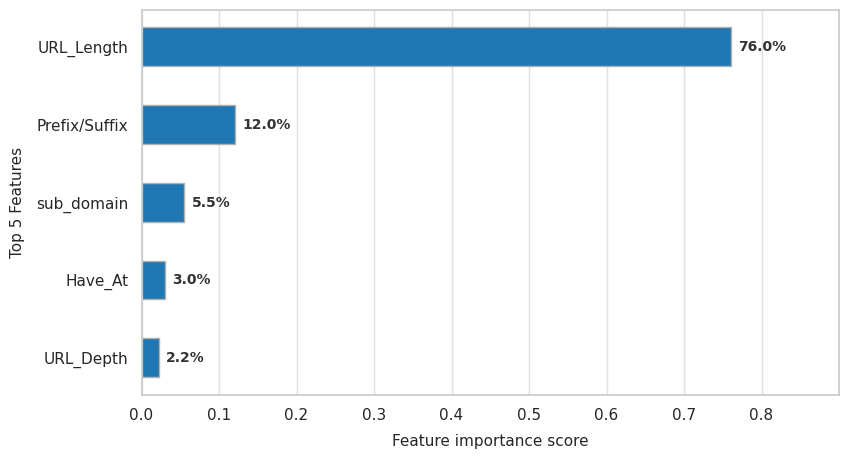

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. إدخال مصفوفة الميزات الكاملة التي قمنا باستخراجها سابقاً
image_data = {
    'Feature': [
        'sub_domain', 'Domain_End', 'Domain_Age', 'Web_Traffic', 'DNS_Record',
        'statistical_report', 'Prefix/Suffix', 'TinyURL', 'https_Domain',
        'Redirection', 'URL_Depth', 'URL_Length', 'Have_At', 'Have_IP'
    ],
    'Feature importance': [
        0.055, 0.010, 0.000, 0.000, 0.000,
        0.000, 0.120, 0.000, 0.000, 0.000,
        0.022, 0.760, 0.030, 0.000
    ]
}

df_full = pd.DataFrame(image_data)

# 2. ترتيب الميزات تناسلياً واختيار أعلى 5 ميزات فقط من حيث الأهمية
df_top5 = df_full.sort_values(by='Feature importance', ascending=False).head(5)

# 3. طباعة الجدول المنسق لأهم 5 ميزات في لوحة التحكم (Console)
print("==============================================")
print("          Top 5 Most Important Features       ")
print("==============================================")
for index, row in df_top5.iterrows():
    print(f"{row['Feature']:<25} | {row['Feature importance']*100:.2f}%")
print("==============================================")

# 4. إعداد نمط الرسم البياني وتوليد شكل توضيحي احترافي لأعلى 5 ميزات
sns.set_theme(style="whitegrid")
plt.figure(figsize=(9, 5))

# رسم الأعمدة أفقياً مع عكس الترتيب ليظهر الأقوى في الأعلى دائماً
bars = plt.barh(df_top5['Feature'][::-1], df_top5['Feature importance'][::-1],
                color='#1f77b4', edgecolor='#b0b0b0', height=0.5)

# إضافة النسبة المئوية الدقيقة بجانب كل عمود لتسهيل القراءة في الأطروحة
for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.01, bar.get_y() + bar.get_height()/2, f'{width*100:.1f}%',
             va='center', ha='left', fontweight='bold', fontsize=10, color='#333333')

# ضبط المحاور والحدود (بدون تحديد خطوط معينة لتفادي التحذيرات)
plt.xlabel('Feature importance score', fontsize=11, labelpad=8)
plt.ylabel('Top 5 Features', fontsize=11, labelpad=8)
plt.xlim(0, 0.9)  # مساحة إضافية لظهور النسب المئوية بوضوح
plt.xticks(np.arange(0, 0.9, 0.1))

# تخصيص خطوط الشبكة الرمادية العمودية فقط
plt.grid(True, axis='x', linestyle='-', color='#e0e0e0', alpha=1.0)
plt.grid(False, axis='y')

# تحسين مظهر الحواف الخارجية للرسم
for spine in plt.gca().spines.values():
    spine.set_color('#cccccc')

# 5. حفظ الصورة بجودة عالية للأطروحة وعرضها
plt.savefig("top_5_phishing_features.png", bbox_inches='tight', dpi=300)
plt.show()


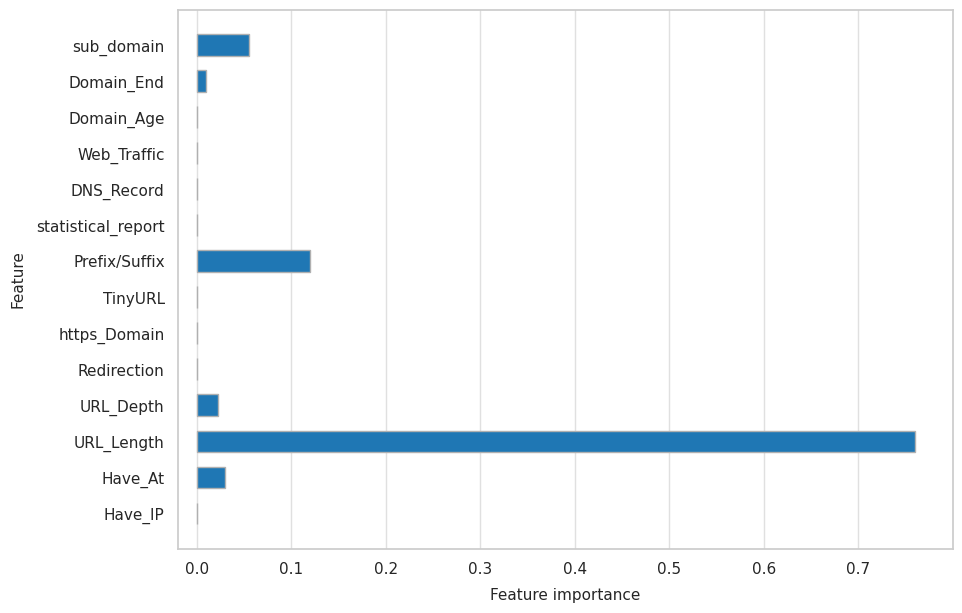

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. إدخل البيانات المطابقة تماماً للصورة
image_data = {
    'Feature': [
        'sub_domain', 'Domain_End', 'Domain_Age', 'Web_Traffic', 'DNS_Record',
        'statistical_report', 'Prefix/Suffix', 'TinyURL', 'https_Domain',
        'Redirection', 'URL_Depth', 'URL_Length', 'Have_At', 'Have_IP'
    ],
    'Feature importance': [
        0.055, 0.010, 0.000, 0.000, 0.000,
        0.000, 0.120, 0.000, 0.000, 0.000,
        0.022, 0.760, 0.030, 0.000
    ]
}

df_chart = pd.DataFrame(image_data)

# 2. إعداد نمط الرسم البياني بدون تحديد خطوط معينة لتجنب التحذيرات
sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 7))

# 3. رسم الأعمدة الأفقية مع عكس الترتيب ليطابق اتجاه الصورة
bars = plt.barh(df_chart['Feature'][::-1], df_chart['Feature importance'][::-1],
                color='#1f77b4', edgecolor='#b0b0b0', height=0.6)

# 4. ضبط محاور الرسم والمسميات (تم إزالة التحديد اليدوي لخط Arial)
plt.xlabel('Feature importance', fontsize=11, labelpad=8)
plt.ylabel('Feature', fontsize=11, labelpad=8)

# ضبط حدود ومواقع الخطوط الشبكية
plt.xlim(-0.02, 0.8)
plt.xticks(np.arange(0, 0.8, 0.1))

# تخصيص خطوط الشبكة الرمادية الدقيقة
plt.grid(True, axis='x', linestyle='-', color='#e0e0e0', alpha=1.0)
plt.grid(False, axis='y')

# تحسين مظهر حواف الرسم الخارجي
for spine in plt.gca().spines.values():
    spine.set_color('#cccccc')

# 5. حفظ الصورة وعرضها بنجاح
plt.savefig("exact_feature_importance_plot.png", bbox_inches='tight', dpi=300)
plt.show()
